# Handshake Job Applications — Data Extraction & Analysis

Parses all 13 saved HTML pages (`0.html` through `12.html`) from Handshake's "My Jobs" page,
extracts structured application data, and runs exploratory analysis.

In [1]:
# ── Install dependencies if needed ──────────────────────────────────────────
# %pip install beautifulsoup4 pandas matplotlib seaborn --quiet

In [2]:
import re
import glob
from pathlib import Path

import pandas as pd
from bs4 import BeautifulSoup

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_colwidth', 80)

## 1. Parse HTML files

Each row's `aria-label` attribute contains the full record as a comma-separated string, e.g.:
```
Employer, ClimateAi. Title, Software Engineering Internship. Location, Remote or onsite, based in New York City, NY. Applied, 5/16/2023. Status, Applied
```

We also extract `industry` from the sub-heading cell and `job_id` from the row's href.

In [3]:
# ── Configuration ────────────────────────────────────────────────────────────
# Adjust this path to wherever your HTML files live.
# Expected layout: ./0.html, ./1.html, ..., ./12.html
# OR:              ./0_files/../0.html style saved pages in the SAME folder.
HTML_DIR = Path('.')          # <-- change if files are in a sub-folder
FILE_PATTERN = '*.html'       # matches 0.html … 12.html

html_files = sorted(HTML_DIR.glob(FILE_PATTERN),
                    key=lambda p: int(re.sub(r'\D', '', p.stem) or -1))
print(f'Found {len(html_files)} HTML file(s):')
for f in html_files:
    print(' ', f)

Found 13 HTML file(s):
  0.html
  1.html
  2.html
  3.html
  4.html
  5.html
  6.html
  7.html
  8.html
  9.html
  10.html
  11.html
  12.html


In [4]:
def parse_aria_label(label: str) -> dict:
    """Extract fields from the row's aria-label string."""
    data = {}

    # Employer
    m = re.search(r'Employer,\s*(.+?)\.\s*Title,', label)
    data['employer'] = m.group(1).strip() if m else None

    # Title
    m = re.search(r'Title,\s*(.+?)\.\s*Location,', label)
    data['title'] = m.group(1).strip() if m else None

    # Full location string
    m = re.search(r'Location,\s*(.+?)\.\s*Applied,', label)
    data['location_raw'] = m.group(1).strip() if m else None

    # Applied date
    m = re.search(r'Applied,\s*(\d+/\d+/\d+)\.', label)
    data['date_applied'] = m.group(1).strip() if m else None

    # Status
    m = re.search(r'Status,\s*(.+)$', label)
    data['status'] = m.group(1).strip() if m else None

    return data


def parse_location(raw: str):
    """Split raw location into work_type, city, state."""
    if not raw:
        return None, None, None

    work_type = None
    if raw.lower().startswith('remote or onsite'):
        work_type = 'Remote/Hybrid'
    elif raw.lower().startswith('onsite'):
        work_type = 'Onsite'
    elif raw.lower().startswith('remote'):
        work_type = 'Remote'

    # Extract "City, ST" — take the FIRST city mentioned after "based in"
    m = re.search(r'based in ([^,]+),\s*([A-Z]{2})(?:[,.]|$)', raw)
    city = m.group(1).strip() if m else None
    state = m.group(2).strip() if m else None

    # Handle international locations (no 2-letter state)
    if not city:
        m2 = re.search(r'based in (.+)', raw)
        city = m2.group(1).strip() if m2 else None

    return work_type, city, state


def parse_file(path: Path) -> list[dict]:
    """Parse one saved HTML page and return a list of row dicts."""
    with open(path, 'r', encoding='utf-8', errors='replace') as fh:
        soup = BeautifulSoup(fh, 'html.parser')

    rows = []
    for tr in soup.select('tr[data-hook]'):          # each application row
        # Primary anchor carries the aria-label
        anchor = tr.select_one('a[aria-label]')
        if not anchor:
            continue

        record = parse_aria_label(anchor.get('aria-label', ''))

        # Job ID from href
        href = anchor.get('href', '')
        jid = re.search(r'/jobs/(\d+)', href)
        record['job_id'] = jid.group(1) if jid else None

        # Industry from sub-heading
        industry_tag = tr.select_one('[data-hook="lockup-subheading"]')
        record['industry'] = industry_tag.get_text(strip=True) if industry_tag else None

        # Source page number
        record['source_page'] = path.stem

        rows.append(record)

    return rows

In [5]:
all_records = []
for f in html_files:
    recs = parse_file(f)
    print(f'{f.name:20s}  →  {len(recs):3d} rows')
    all_records.extend(recs)

print(f'\nTotal records extracted: {len(all_records)}')

0.html                →   50 rows
1.html                →   50 rows
2.html                →   50 rows
3.html                →   50 rows
4.html                →   50 rows
5.html                →    0 rows
6.html                →   50 rows
7.html                →   50 rows
8.html                →   50 rows
9.html                →   50 rows
10.html               →   50 rows
11.html               →   50 rows
12.html               →   20 rows

Total records extracted: 570


## 2. Build & clean the DataFrame

In [6]:
df = pd.DataFrame(all_records)

# Parse location into components
loc = df['location_raw'].apply(lambda x: pd.Series(parse_location(x),
                                                    index=['work_type', 'city', 'state']))
df = pd.concat([df, loc], axis=1)

# Parse date
df['date_applied'] = pd.to_datetime(df['date_applied'], format='%m/%d/%Y', errors='coerce')
df['year_applied']  = df['date_applied'].dt.year
df['month_applied'] = df['date_applied'].dt.to_period('M')

# Normalise status
df['status'] = df['status'].str.strip().str.title()

# Drop exact duplicates (same job_id applied once)
df = df.drop_duplicates(subset='job_id').reset_index(drop=True)

print(df.shape)
df.head(10)

(570, 13)


,employer,title,location_raw,date_applied,status,job_id,industry,source_page,work_type,city,state,year_applied,month_applied
0,Sony Music Entertainment,Environmental Social Governance Specialist,"Onsite, based in Los Angeles, CA",2026-05-08,Applied,11022175,"Movies, TV, Music, Gaming",0,Onsite,Los Angeles,CA,2026,2026-05
1,Heartflow,Make an Impact - Imaging Analyst at Heartflow - Training included,"Hybrid, based in Austin, TX",2026-05-08,Applied,11005041,Medical Devices,0,None,Austin,TX,2026,2026-05
2,Cobbs Creek Healthcare,Data Analyst - Junior,"Onsite, based in Newtown Square, PA",2026-04-29,Applied,10905518,Pharmaceuticals,0,Onsite,Newtown Square,PA,2026,2026-04
3,Walther Farms,IT Systems & Data Administrator,"Hybrid or onsite, based in Three Rivers, MI",2026-04-29,Applied,10997336,Agriculture,0,None,Three Rivers,MI,2026,2026-04
4,Ekimetrics,"Junior Business Scientist, Data Science and Marketing Effectiveness","Hybrid, based in New York, NY",2026-04-29,Applied,10935270,Scientific and Technical Consulting,0,None,New York,NY,2026,2026-04
5,Tenzing Global Management,Analyst,"Onsite, based in San Francisco, CA",2026-04-29,Applied,10953417,Investment / Portfolio Management,0,Onsite,San Francisco,CA,2026,2026-04
6,Oakmont Education,Data Analytics Marketing Intern,"Onsite, based in Fairlawn, OH",2026-04-29,Applied,10957465,K-12 Education,0,Onsite,Fairlawn,OH,2026,2026-04
7,Novateur Research Solutions,Junior Linux Systems Administrator,"Onsite, based in Ashburn, VA",2026-04-26,Applied,10975080,Research,0,Onsite,Ashburn,VA,2026,2026-04
8,Bose Corporation (MA),Entry-Level NLP Data Scientist,"Hybrid, based in Framingham, MA",2026-04-25,Applied,10955911,Electronic & Computer Hardware,0,None,Framingham,MA,2026,2026-04
9,Preference Model,Machine Learning Engineer (New Grad),"Onsite, based in San Francisco, CA",2026-04-20,Applied,10964904,Internet & Software,0,Onsite,San Francisco,CA,2026,2026-04


In [7]:
# Column overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 570 entries, 0 to 569
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   employer       570 non-null    object        
 1   title          570 non-null    object        
 2   location_raw   570 non-null    object        
 3   date_applied   570 non-null    datetime64[ns]
 4   status         570 non-null    object        
 5   job_id         569 non-null    object        
 6   industry       559 non-null    object        
 7   source_page    570 non-null    object        
 8   work_type      381 non-null    object        
 9   city           551 non-null    object        
 10  state          510 non-null    object        
 11  year_applied   570 non-null    int32         
 12  month_applied  570 non-null    period[M]     
dtypes: datetime64[ns](1), int32(1), object(10), period[M](1)
memory usage: 55.8+ KB


In [8]:
# Quick value counts for key fields
print('=== Status ===')
print(df['status'].value_counts(), '\n')

print('=== Work type ===')
print(df['work_type'].value_counts(), '\n')

print('=== Top 10 states ===')
print(df['state'].value_counts().head(10))

=== Status ===
status
Applied     530
Declined     29
Closed       11
Name: count, dtype: int64 

=== Work type ===
work_type
Onsite           286
Remote            59
Remote/Hybrid     36
Name: count, dtype: int64 

=== Top 10 states ===
state
CA    132
NY     84
IL     66
MI     37
TX     27
FL     23
VA     19
MA     17
PA     14
NJ     13
Name: count, dtype: int64


## 3. Analysis & Visualisations

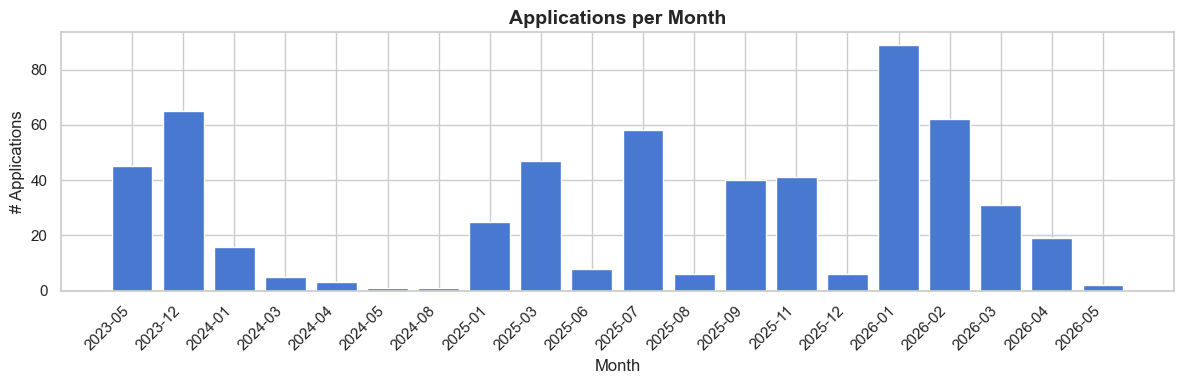

In [9]:
# ── 3.1  Applications over time ──────────────────────────────────────────────
monthly = (df.groupby('month_applied')
             .size()
             .reset_index(name='count')
             .sort_values('month_applied'))
monthly['month_str'] = monthly['month_applied'].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly['month_str'], monthly['count'], color=sns.color_palette('muted')[0])
ax.set_title('Applications per Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('# Applications')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

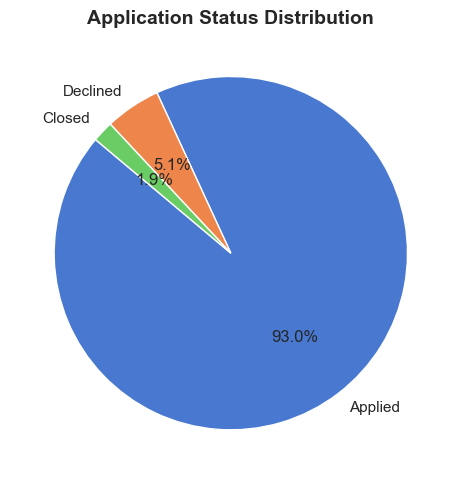

In [10]:
# ── 3.2  Application status breakdown ────────────────────────────────────────
status_counts = df['status'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
colors = sns.color_palette('muted', len(status_counts))
wedges, texts, autotexts = ax.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)
ax.set_title('Application Status Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/9b/pqv3317s0y7gshfwzdd28mfw0000gn/T/ipykernel_51425/934078732.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_industries.values, y=top_industries.index, ax=ax,


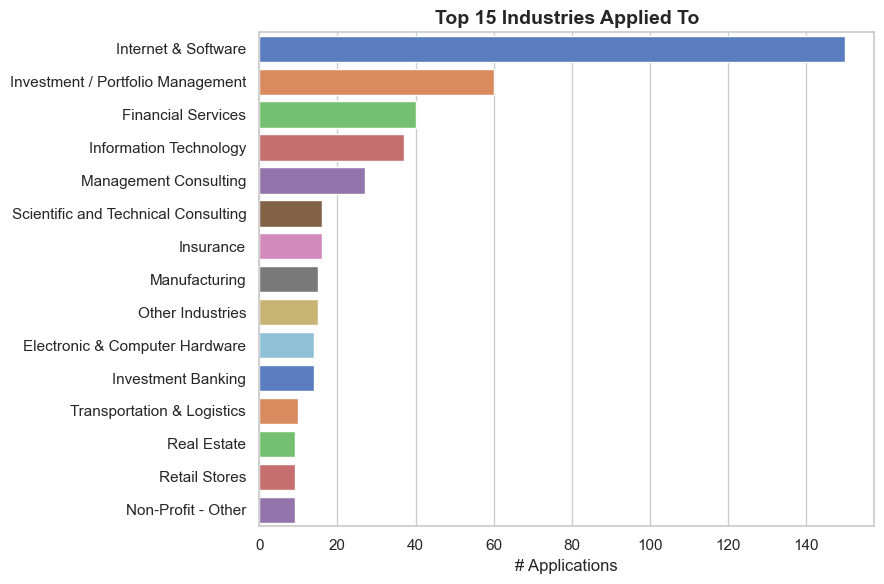

In [11]:
# ── 3.3  Top industries ───────────────────────────────────────────────────────
top_industries = df['industry'].value_counts().dropna().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_industries.values, y=top_industries.index, ax=ax,
            palette='muted')
ax.set_title('Top 15 Industries Applied To', fontsize=14, fontweight='bold')
ax.set_xlabel('# Applications')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

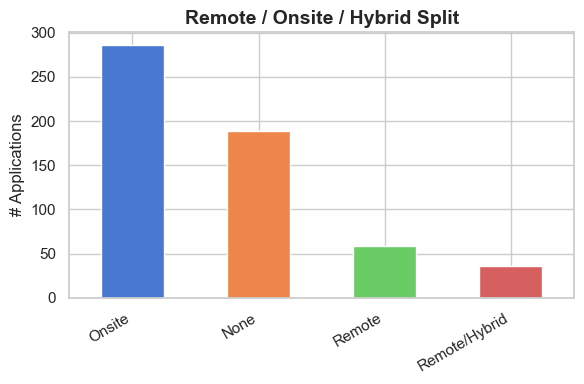

In [12]:
# ── 3.4  Work type breakdown ──────────────────────────────────────────────────
wt = df['work_type'].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(6, 4))
wt.plot(kind='bar', ax=ax, color=sns.color_palette('muted', len(wt)), edgecolor='white')
ax.set_title('Remote / Onsite / Hybrid Split', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('# Applications')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

/var/folders/9b/pqv3317s0y7gshfwzdd28mfw0000gn/T/ipykernel_51425/4252627144.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.index, y=top_states.values, ax=ax, palette='muted')


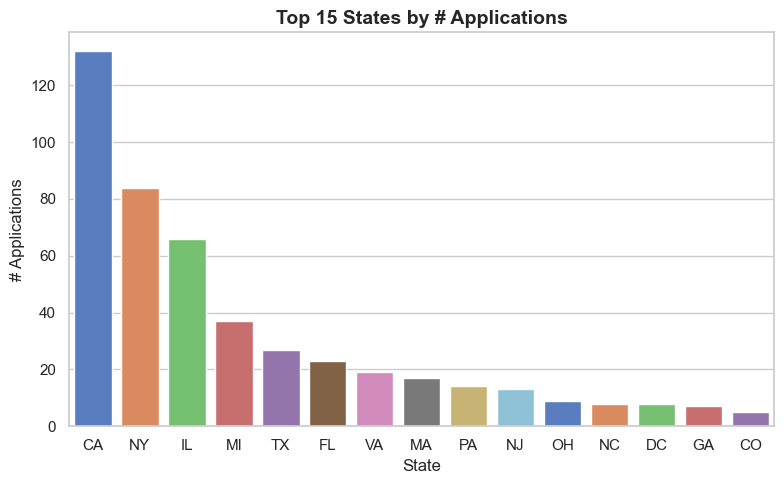

In [13]:
# ── 3.5  Top states ───────────────────────────────────────────────────────────
top_states = df['state'].value_counts().dropna().head(15)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top_states.index, y=top_states.values, ax=ax, palette='muted')
ax.set_title('Top 15 States by # Applications', fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('# Applications')
plt.tight_layout()
plt.show()

/var/folders/9b/pqv3317s0y7gshfwzdd28mfw0000gn/T/ipykernel_51425/1903696409.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_emp.values, y=top_emp.index, ax=ax, palette='muted')


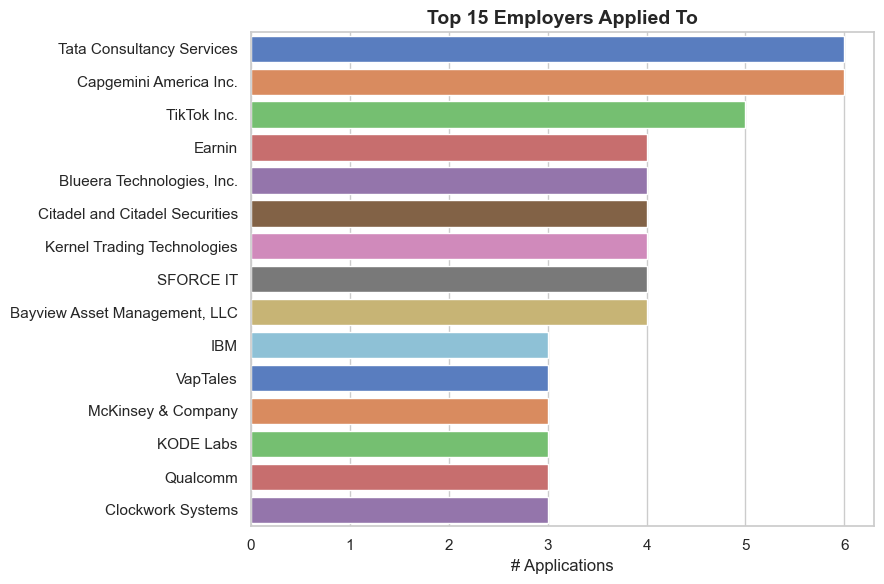

In [14]:
# ── 3.6  Top employers ────────────────────────────────────────────────────────
top_emp = (df[df['employer'] != 'Inactive employer']
           ['employer'].value_counts().head(15))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_emp.values, y=top_emp.index, ax=ax, palette='muted')
ax.set_title('Top 15 Employers Applied To', fontsize=14, fontweight='bold')
ax.set_xlabel('# Applications')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

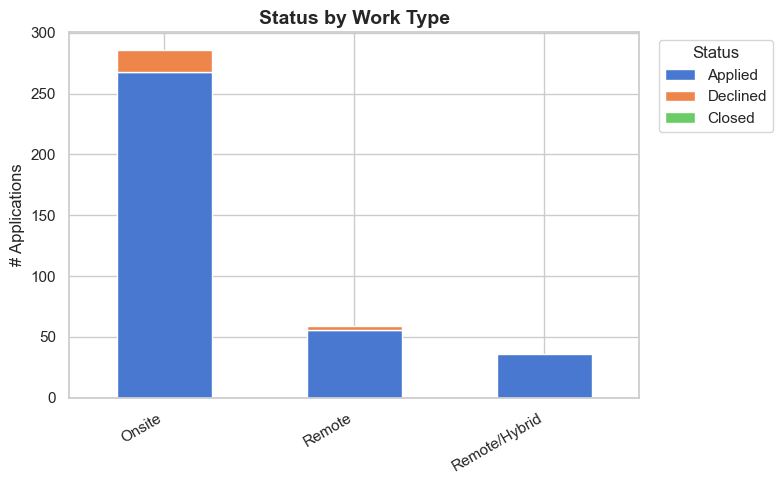

In [15]:
# ── 3.7  Status by work type (stacked bar) ───────────────────────────────────
cross = (df.groupby(['work_type', 'status'])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=df['status'].value_counts().index))

cross.plot(kind='bar', stacked=True, figsize=(8, 5),
           color=sns.color_palette('muted', cross.shape[1]),
           edgecolor='white')
plt.title('Status by Work Type', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('# Applications')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [16]:
# ── 3.8  Summary stats ───────────────────────────────────────────────────────
total          = len(df)
active         = (df['status'] == 'Applied').sum()
closed         = (df['status'] == 'Closed').sum()
declined       = (df['status'] == 'Declined').sum()
hired          = (df['status'] == 'Hired').sum()
date_range     = f"{df['date_applied'].min().date()}  →  {df['date_applied'].max().date()}"
unique_emp     = df[df['employer'] != 'Inactive employer']['employer'].nunique()

print('━' * 45)
print('  SUMMARY')
print('━' * 45)
print(f'  Total applications  : {total}')
print(f'  Date range          : {date_range}')
print(f'  Unique employers    : {unique_emp}')
print(f'  Status — Applied    : {active}')
print(f'  Status — Closed     : {closed}')
print(f'  Status — Declined   : {declined}')
print(f'  Status — Hired      : {hired}')
print('━' * 45)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total applications  : 570
  Date range          : 2023-05-06  →  2026-05-08
  Unique employers    : 434
  Status — Applied    : 530
  Status — Closed     : 11
  Status — Declined   : 29
  Status — Hired      : 0
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 4. State Distribution — Inline Summary

In [17]:
# ── 3.9  All states as inline percentages ────────────────────────────────────
state_pct = (
    df['state']
    .value_counts(dropna=False)
    .pipe(lambda s: (s / s.sum() * 100).round(1))
)

# Replace NaN label with readable text
state_pct.index = state_pct.index.fillna('Unknown/Intl')

# Format as comma-separated inline string
inline = '  |  '.join(f"{state}: {pct}%" for state, pct in state_pct.items())
print('State breakdown (% of all applications)\n')
print(inline)

State breakdown (% of all applications)

CA: 23.2%  |  NY: 14.7%  |  IL: 11.6%  |  Unknown/Intl: 10.5%  |  MI: 6.5%  |  TX: 4.7%  |  FL: 4.0%  |  VA: 3.3%  |  MA: 3.0%  |  PA: 2.5%  |  NJ: 2.3%  |  OH: 1.6%  |  DC: 1.4%  |  NC: 1.4%  |  GA: 1.2%  |  CO: 0.9%  |  WI: 0.7%  |  MN: 0.7%  |  SC: 0.7%  |  AZ: 0.7%  |  TN: 0.5%  |  WA: 0.5%  |  UT: 0.4%  |  CT: 0.4%  |  MS: 0.4%  |  ME: 0.4%  |  NV: 0.4%  |  MD: 0.2%  |  IN: 0.2%  |  SD: 0.2%  |  IA: 0.2%  |  HI: 0.2%  |  AR: 0.2%  |  LA: 0.2%  |  DE: 0.2%  |  AK: 0.2%


## 5. Export clean DataFrame to CSV

In [18]:
export_cols = ['job_id', 'employer', 'industry', 'title',
               'location_raw', 'work_type', 'city', 'state',
               'date_applied', 'status', 'source_page']

out_path = 'handshake_applications.csv'
df[export_cols].to_csv(out_path, index=False)
print(f'Saved → {out_path}  ({len(df)} rows)')

Saved → handshake_applications.csv  (570 rows)
